#🏢Telecom X - Análise de Evasão de Clientes
Análise de dados na Telecom X para desenvolvimento do projeto "Churn de Clientes". A empresa enfrenta um alto índice de cancelamentos e precisa entender os fatores que levam à perda de clientes.

#✔️ Bibliotecas

In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json

#📌 Extracão

In [349]:
# Extração dos dados via API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

try:
    # Obtendo o JSON bruto via requests
    response = requests.get(url)
    data = response.json()

    # json_normalize transforma {'Charges': {'Total': 100}} em Charges.Total
    df = pd.json_normalize(data)
    print(f"Dados carregados e normalizados com sucesso! Total de registros: {len(df)}")
except Exception as e:
    print(f"Erro ao processar o JSON: {e}")

print('---------------------------------------------------------------------')
print("Colunas após normalização:", df.columns.tolist())

Dados carregados e normalizados com sucesso! Total de registros: 7267
---------------------------------------------------------------------
Colunas após normalização: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


#🔧 Transformação

In [350]:
# Exibir as primeiras linhas do DataFrame pronto
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [351]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [352]:
# PADRONIZAÇÃO DAS COLUNAS

# Convertendo pontos em underscores e transformando tudo em minúsculo
df.columns = [col.replace('.', '_').lower() for col in df.columns]

# Verificando como ficaram os nomes das colunas
print("Colunas padronizadas:\n", df.columns.tolist())

Colunas padronizadas:
 ['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen', 'customer_partner', 'customer_dependents', 'customer_tenure', 'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice', 'internet_onlinesecurity', 'internet_onlinebackup', 'internet_deviceprotection', 'internet_techsupport', 'internet_streamingtv', 'internet_streamingmovies', 'account_contract', 'account_paperlessbilling', 'account_paymentmethod', 'account_charges_monthly', 'account_charges_total']


In [353]:
# IDENTIFICAÇÃO DE COLUNAS COM YES/NO

print("Colunas que contêm 'Yes' e 'No' e seus valores únicos:\n")

colunas_yes_no = []

for col in df.columns:
    # Verifica apenas colunas do tipo texto/objeto (pula numéricas)
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        valores_unicos = df[col].unique()

        # Verifica se 'Yes' e 'No' estão presentes nos valores da coluna
        if 'Yes' in valores_unicos and 'No' in valores_unicos:
            colunas_yes_no.append(col)
            print(f"Coluna: {col}")
            print(f"Valores: {valores_unicos}\n{'-'*30}")

print(f"\nTotal de colunas encontradas: {len(colunas_yes_no)}")

Colunas que contêm 'Yes' e 'No' e seus valores únicos:

Coluna: churn
Valores: ['No' 'Yes' '']
------------------------------
Coluna: customer_partner
Valores: ['Yes' 'No']
------------------------------
Coluna: customer_dependents
Valores: ['Yes' 'No']
------------------------------
Coluna: phone_phoneservice
Valores: ['Yes' 'No']
------------------------------
Coluna: phone_multiplelines
Valores: ['No' 'Yes' 'No phone service']
------------------------------
Coluna: internet_onlinesecurity
Valores: ['No' 'Yes' 'No internet service']
------------------------------
Coluna: internet_onlinebackup
Valores: ['Yes' 'No' 'No internet service']
------------------------------
Coluna: internet_deviceprotection
Valores: ['No' 'Yes' 'No internet service']
------------------------------
Coluna: internet_techsupport
Valores: ['Yes' 'No' 'No internet service']
------------------------------
Coluna: internet_streamingtv
Valores: ['Yes' 'No' 'No internet service']
------------------------------
Coluna

In [354]:
# Definindo a lista de todas as colunas que possuem variações de Yes/No
# Com base na verificação anterior
colunas_para_mapear = [
    'churn', 'customer_partner', 'customer_dependents',
    'phone_phoneservice', 'phone_multiplelines', 'internet_onlinesecurity',
    'internet_onlinebackup', 'internet_deviceprotection', 'internet_techsupport',
    'internet_streamingtv', 'internet_streamingmovies', 'account_paperlessbilling'
]

# 3. Mapeamento Lógico:
# Tudo que começa com 'No' (inclusive 'No internet service') vira 0
# Tudo que é 'Yes' vira 1
for col in colunas_para_mapear:
    df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

In [355]:
# Verificação final variações de Yes/No
print("Amostra dos dados mapeados (0 e 1):")
display(df[colunas_para_mapear].head())

Amostra dos dados mapeados (0 e 1):


,churn,customer_partner,customer_dependents,phone_phoneservice,phone_multiplelines,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_paperlessbilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,0,0,0,1,1,0,0,0,0,0,1,0
2,1,0,0,1,0,0,0,1,0,0,0,1
3,1,1,0,1,0,0,1,1,0,1,1,1
4,1,1,0,1,0,0,0,0,1,1,0,1


In [356]:
print("\nTipos de dados atuais:")
print(df[colunas_para_mapear].dtypes)


Tipos de dados atuais:
churn                        int64
customer_partner             int64
customer_dependents          int64
phone_phoneservice           int64
phone_multiplelines          int64
internet_onlinesecurity      int64
internet_onlinebackup        int64
internet_deviceprotection    int64
internet_techsupport         int64
internet_streamingtv         int64
internet_streamingmovies     int64
account_paperlessbilling     int64
dtype: object


In [357]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7267 non-null   int64  
 2   customer_gender            7267 non-null   object 
 3   customer_seniorcitizen     7267 non-null   int64  
 4   customer_partner           7267 non-null   int64  
 5   customer_dependents        7267 non-null   int64  
 6   customer_tenure            7267 non-null   int64  
 7   phone_phoneservice         7267 non-null   int64  
 8   phone_multiplelines        7267 non-null   int64  
 9   internet_internetservice   7267 non-null   object 
 10  internet_onlinesecurity    7267 non-null   int64  
 11  internet_onlinebackup      7267 non-null   int64  
 12  internet_deviceprotection  7267 non-null   int64  
 13  internet_techsupport       7267 non-null   int64

In [358]:
# Conversão da coluna account_charges_total
# errors='coerce' é vital para lidar com espaços vazios que causam erro na conversão manual
df['account_charges_total'] = pd.to_numeric(df['account_charges_total'], errors='coerce')

# 3. Verificação de valores nulos gerados
nulos_apos_conversao = df['account_charges_total'].isnull().sum()

print(f"Quantidade de valores nulos (vazios) encontrados em 'account_charges_total': {nulos_apos_conversao}")
print("\nVerificação do Dtype atualizado:")
print(df[['account_charges_total']].info())

Quantidade de valores nulos (vazios) encontrados em 'account_charges_total': 11

Verificação do Dtype atualizado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   account_charges_total  7256 non-null   float64
dtypes: float64(1)
memory usage: 56.9 KB
None


In [359]:
# VERIFICAÇÃO DE VAZIOS E ESPAÇOS NA COLUNA CHURN

# Contando valores Nulos (NaN)
nulos_reais = df['churn'].isnull().sum()

# Contando espaços em branco (strings vazias ou apenas com espaços)
# O strip() remove espaços nas extremidades; se o resultado for '', era um campo "vazio"
espacos_em_branco = (df['churn'].astype(str).str.strip() == '').sum()

# Verificando se existem valores diferentes de "Yes" ou "No" (antes do mapeamento)
valores_inesperados = df[~df['churn'].isin(['Yes', 'No'])]['churn'].unique()

print(f"Registros com valores nulos (NaN): {nulos_reais}")
print(f"Registros que são apenas espaços em branco: {espacos_em_branco}")
print(f"Valores fora do padrão 'Yes'/'No' encontrados: {valores_inesperados}")

# Exibindo a contagem atual para garantir que não há sujeira
print("\nDistribuição atual da coluna Churn:")
print(df['churn'].value_counts())

Registros com valores nulos (NaN): 0
Registros que são apenas espaços em branco: 0
Valores fora do padrão 'Yes'/'No' encontrados: [0 1]

Distribuição atual da coluna Churn:
churn
0    5398
1    1869
Name: count, dtype: int64


In [360]:
# VERIFICAÇÃO DE VALORES NULOS

# Calculando nulos absolutos e a porcentagem
nulos_totais = df.isnull().sum()
nulos_percentual = (df.isnull().sum() / len(df)) * 100

# Criando uma tabela de resumo para facilitar a leitura
resumo_nulos = pd.DataFrame({
    'Quantidade de Nulos': nulos_totais,
    'Porcentagem (%)': nulos_percentual.round(2)
})

# Filtrando apenas as colunas que possuem ao menos 1 nulo
resumo_nulos = resumo_nulos[resumo_nulos['Quantidade de Nulos'] > 0]

if resumo_nulos.empty:
    print("Sucesso! Nenhuma coluna possui valores nulos no momento.")
else:
    print("Colunas com valores nulos identificadas:")
    display(resumo_nulos)

# Verificação extra: Contar strings que são apenas espaços vazios " " em todo o DF
espacos_vazios = (df.apply(lambda x: x.astype(str).str.strip() == '').sum()).sum()
print(f"\nTotal de células que contêm apenas espaços em branco no DataFrame: {espacos_vazios}")

Colunas com valores nulos identificadas:


,Quantidade de Nulos,Porcentagem (%)
account_charges_total,11,0.15



Total de células que contêm apenas espaços em branco no DataFrame: 0


In [361]:
# TRATAMENTO DE NULOS ---

# Verificando a quantidade antes da exclusão
print(f"Total de registros antes: {len(df)}")

# Removendo as linhas onde account_charges_total é nulo
# Escolhi pela exclusão pois a quantidade é mínima e evita viés estatístico
df = df.dropna(subset=['account_charges_total'])

# 4. Verificação Final
print(f"Total de registros após a limpeza: {len(df)}")
print(f"Nulos restantes em account_charges_total: {df['account_charges_total'].isnull().sum()}")

# Resetando o índice após a remoção das linhas
df = df.reset_index(drop=True)

Total de registros antes: 7267
Total de registros após a limpeza: 7256
Nulos restantes em account_charges_total: 0


In [362]:
# CRIAÇÃO DA COLUNA CONTAS_DIARIAS

# Cálculo da conta diária baseada no faturamento mensal
# Usei a coluna 'account_charges_monthly' dividida por 30
df['account_charges_daily'] = (df['account_charges_monthly'] / 30).round(2)

# 4. Verificação da nova coluna
print("Amostra das cobranças mensais vs. diárias:")
display(df[['account_charges_monthly', 'account_charges_daily']].head())
df = df.reset_index(drop=True)

Amostra das cobranças mensais vs. diárias:


,account_charges_monthly,account_charges_daily
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [363]:
# Verificação do Dtype
print("\nInformações sobre a nova coluna:")
print(df.info())


Informações sobre a nova coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7256 non-null   object 
 1   churn                      7256 non-null   int64  
 2   customer_gender            7256 non-null   object 
 3   customer_seniorcitizen     7256 non-null   int64  
 4   customer_partner           7256 non-null   int64  
 5   customer_dependents        7256 non-null   int64  
 6   customer_tenure            7256 non-null   int64  
 7   phone_phoneservice         7256 non-null   int64  
 8   phone_multiplelines        7256 non-null   int64  
 9   internet_internetservice   7256 non-null   object 
 10  internet_onlinesecurity    7256 non-null   int64  
 11  internet_onlinebackup      7256 non-null   int64  
 12  internet_deviceprotection  7256 non-null   int64  
 13  internet_techs

In [364]:
# TRADUÇÃO DAS COLUNAS

dicionario_colunas = {
    'customerid': 'id_cliente',
    'churn': 'evasao',
    'customer_gender': 'genero',
    'customer_seniorcitizen': 'idoso',
    'customer_partner': 'parceiro',
    'customer_dependents': 'dependentes',
    'customer_tenure': 'meses_contrato',
    'phone_phoneservice': 'servico_telefone',
    'phone_multiplelines': 'multiplas_linhas',
    'internet_internetservice': 'provedor_internet',
    'internet_onlinesecurity': 'seguranca_online',
    'internet_onlinebackup': 'backup_online',
    'internet_deviceprotection': 'protecao_dispositivo',
    'internet_techsupport': 'suporte_tecnico',
    'internet_streamingtv': 'streaming_tv',
    'internet_streamingmovies': 'streaming_filmes',
    'account_contract': 'tipo_contrato',
    'account_paperlessbilling': 'fatura_online',
    'account_paymentmethod': 'forma_pagamento',
    'account_charges_monthly': 'valor_mensal',
    'account_charges_total': 'valor_total',
    'account_charges_daily': 'valor_diario'
}

df = df.rename(columns=dicionario_colunas)

In [365]:
# TRADUÇÃO DOS VALORES INTERNOS

# Traduzindo tipos de genero
mapa_genero = {
    'Female': 'Feminino',
    'Male': 'Masculino'
}
df['genero'] = df['genero'].replace(mapa_genero)

# Traduzindo tipos de contrato
mapa_contrato = {
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal'
}
df['tipo_contrato'] = df['tipo_contrato'].replace(mapa_contrato)

# Traduzindo formas de pagamento
mapa_pagamento = {
    'Electronic check': 'Check Eletrônico',
    'Mailed check': 'Check via Correio',
    'Bank transfer (automatic)': 'Transferência Bancária',
    'Credit card (automatic)': 'Cartão de Crédito'
}
df['forma_pagamento'] = df['forma_pagamento'].replace(mapa_pagamento)

# Traduzindo tipos de internet
mapa_internet = {
    'Fiber optic': 'Fibra Óptica',
    'DSL': 'DSL',
    'No': 'Nenhum'
}
df['provedor_internet'] = df['provedor_internet'].replace(mapa_internet)


In [366]:
# Verificando o resultado final da tradução
print("Colunas traduzidas:")
print(df.columns.tolist())

print("\nExemplo dos dados traduzidos:")
display(df[['id_cliente', 'tipo_contrato', 'genero', 'forma_pagamento', 'evasao']].head())

Colunas traduzidas:
['id_cliente', 'evasao', 'genero', 'idoso', 'parceiro', 'dependentes', 'meses_contrato', 'servico_telefone', 'multiplas_linhas', 'provedor_internet', 'seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'fatura_online', 'forma_pagamento', 'valor_mensal', 'valor_total', 'valor_diario']

Exemplo dos dados traduzidos:


,id_cliente,tipo_contrato,genero,forma_pagamento,evasao
0,0002-ORFBO,Anual,Feminino,Check via Correio,0
1,0003-MKNFE,Mensal,Masculino,Check via Correio,0
2,0004-TLHLJ,Mensal,Masculino,Check Eletrônico,1
3,0011-IGKFF,Mensal,Masculino,Check Eletrônico,1
4,0013-EXCHZ,Mensal,Feminino,Check via Correio,1


In [367]:
# REORDENAÇÃO DAS COLUNAS

# Criando a nova ordem: valor_diario antes de valor_mensal
colunas = list(df.columns)
# Removemos as colunas de suas posições atuais para reinseri-las na ordem desejada
colunas.remove('valor_diario')
index_mensal = colunas.index('valor_mensal')
colunas.insert(index_mensal, 'valor_diario')

# Aplicando a nova ordem ao DataFrame
df = df[colunas]

# Verificação do resultado
print("Ordem das colunas financeiras:")
display(df[['valor_diario', 'valor_mensal', 'valor_total']].head())

Ordem das colunas financeiras:


,valor_diario,valor_mensal,valor_total
0,2.19,65.6,593.30
1,2.00,59.9,542.40
2,2.46,73.9,280.85
3,3.27,98.0,1237.85
4,2.80,83.9,267.40


In [368]:
df.head(10)

,id_cliente,evasao,genero,idoso,parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,provedor_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,forma_pagamento,valor_diario,valor_mensal,valor_total
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Check via Correio,2.19,65.60,593.30
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Check via Correio,2.00,59.90,542.40
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Óptica,...,1,0,0,0,Mensal,1,Check Eletrônico,2.46,73.90,280.85
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Óptica,...,1,0,1,1,Mensal,1,Check Eletrônico,3.27,98.00,1237.85
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fibra Óptica,...,0,1,1,0,Mensal,1,Check via Correio,2.80,83.90,267.40
5,0013-MHZWF,0,Feminino,0,0,1,9,1,0,DSL,...,0,1,1,1,Mensal,1,Cartão de Crédito,2.31,69.40,571.45
6,0013-SMEOE,0,Feminino,1,1,0,71,1,0,Fibra Óptica,...,1,1,1,1,Bienal,1,Transferência Bancária,3.66,109.70,7904.25
7,0014-BMAQU,0,Masculino,0,1,0,63,1,1,Fibra Óptica,...,0,1,0,0,Bienal,1,Cartão de Crédito,2.82,84.65,5377.80
8,0015-UOCOJ,0,Feminino,1,0,0,7,1,0,DSL,...,0,0,0,0,Mensal,1,Check Eletrônico,1.61,48.20,340.35
9,0016-QLJIS,0,Feminino,0,1,1,65,1,1,DSL,...,1,1,1,1,Bienal,1,Check via Correio,3.02,90.45,5957.90


#📊 Carga e análise

In [374]:
# MAPEAMENTO DE RÓTULOS PARA EVASÃO

# Mapeando diretamente para facilitar a leitura visual
# 0 vira 'Fica' e 1 vira 'Saiu'
df['status_evasao'] = df['evasao'].map({0: 'Fica', 1: 'Saiu'})

In [375]:
# ANÁLISE DESCRITIVA SEGMENTADA
dist_evasao = df['evasao'].value_counts(normalize=True).mul(100).reset_index(name='Proporcao')
dist_evasao['evasao'] = dist_evasao['evasao'].map({0: 'Permanecera', 1: 'Cancelou'})

print('Proporção de Churn (%)')
display(dist_evasao)

Proporção de Churn (%)


,evasao,Proporcao
0,Permanecera,74.242007
1,Cancelou,25.757993


In [376]:
# Selecionando colunas numéricas de interesse
colunas_financeiras = ['meses_contrato', 'valor_mensal']

# Agrupando pelo novo rótulo e calculando métricas
estatisticas_status = df.groupby('status_evasao')[colunas_financeiras].agg(['mean', 'median', 'std']).round(2)

print("Métricas Descritivas por Status de Evasão:")
display(estatisticas_status)

Métricas Descritivas por Status de Evasão:


meses_contrato               valor_mensal              
                        mean median    std         mean median    std
status_evasao                                                        
Fica                   37.40   37.0  24.14        61.39  64.55  31.11
Saiu                   17.98   10.0  19.53        74.44  79.65  24.67

/tmp/ipython-input-1844368734.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='evasao', palette=cores_churn, ax=ax[0])
/tmp/ipython-input-1844368734.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Permanecera', 'Cancelou'])


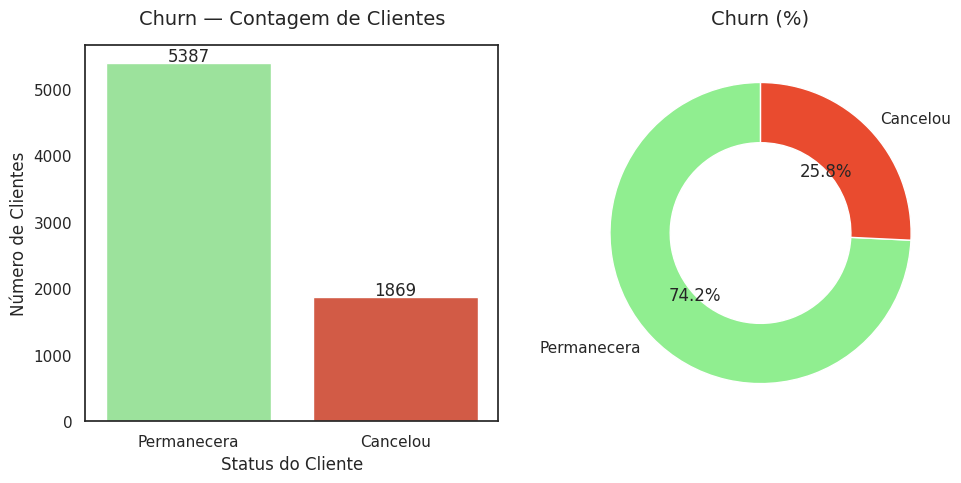

In [377]:
# Configuração de estilo para um visual limpo e executivo
sns.set_style("white")
cores_churn = ["#90EE90", "#e94b2f"] # Verde para 'Fica' e Vermelho para 'Saiu'

# Criando a figura com dois gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Gráfico de Barras (Contagem Absoluta)
sns.countplot(data=df, x='evasao', palette=cores_churn, ax=ax[0])
ax[0].set_title('Churn — Contagem de Clientes', fontsize=14, pad=15)
ax[0].set_xticklabels(['Permanecera', 'Cancelou'])
ax[0].set_xlabel('Status do Cliente')
ax[0].set_ylabel('Número de Clientes')

# Adicionando rótulos de dados nas barras
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 5),
                   textcoords = 'offset points')

# Gráfico de Rosca (Proporção Percentual)
labels = ['Permanecera', 'Cancelou']
valores = df['evasao'].value_counts()
ax[1].pie(valores, labels=labels, autopct='%1.1f%%', startangle=90, colors=cores_churn, wedgeprops={'width': 0.4})
ax[1].set_title('Churn (%)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2798022639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='evasao', y='meses_contrato', data=df, palette=["#90EE90", "#e94b2f"])  # Verde para 'Fica' e Vermelho para 'Saiu'


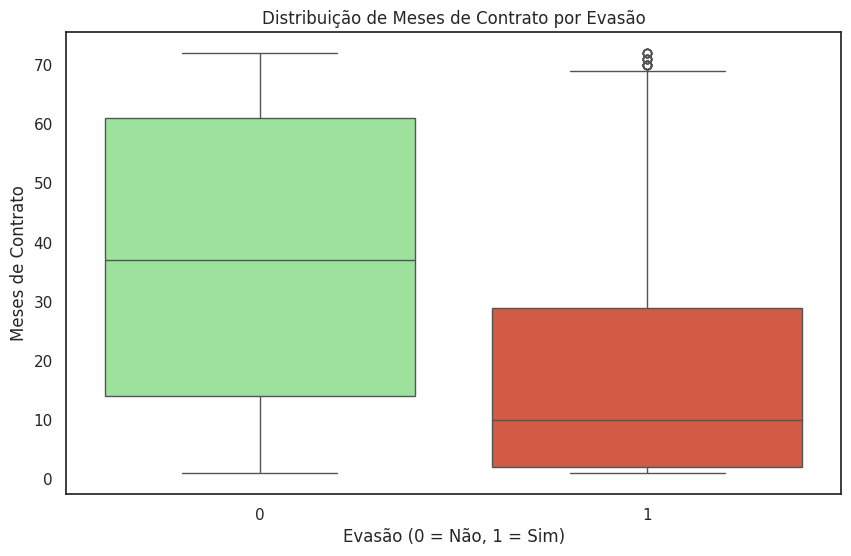

In [378]:
# Criando um Boxplot para comparar o Tempo de Contrato (Tenure) entre os grupos
plt.figure(figsize=(10, 6))
sns.boxplot(x='evasao', y='meses_contrato', data=df, palette=["#90EE90", "#e94b2f"])  # Verde para 'Fica' e Vermelho para 'Saiu'
plt.title('Distribuição de Meses de Contrato por Evasão')
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

/tmp/ipython-input-20547546.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_impacto, x='Valor', y='Categoria', palette=cores_impacto)


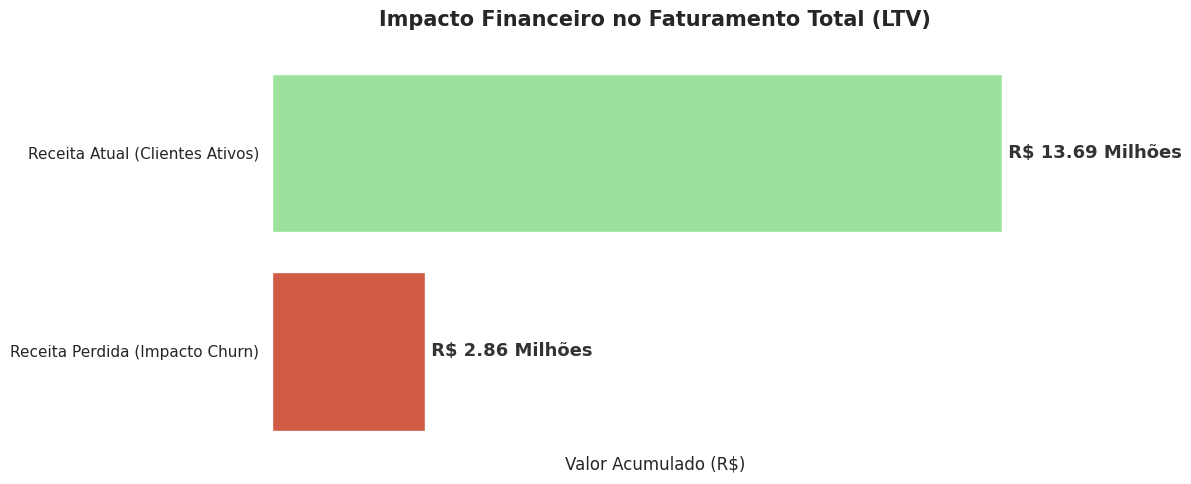

In [379]:
# Configuração de estilo executivo
sns.set_style("white")
cores_impacto = ["#90EE90", "#e94b2f"]  # Verde para 'Fica' e Vermelho para 'Saiu'

# PREPARAÇÃO DOS DADOS FINANCEIROS
# Somando o 'valor_total' (Charges.Total) para cada grupo
receita_retida = df[df['evasao'] == 0]['valor_total'].sum()
receita_perdida = df[df['evasao'] == 1]['valor_total'].sum()

# Criando um DataFrame para o gráfico
df_impacto = pd.DataFrame({
    'Categoria': ['Receita Atual (Clientes Ativos)', 'Receita Perdida (Impacto Churn)'],
    'Valor': [receita_retida, receita_perdida]
})

# GRÁFICO DE BARRAS HORIZONTAL
plt.figure(figsize=(12, 5))

ax = sns.barplot(data=df_impacto, x='Valor', y='Categoria', palette=cores_impacto)

# Títulos e Rótulos
plt.title('Impacto Financeiro no Faturamento Total (LTV)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Valor Acumulado (R$)', fontsize=12)
plt.ylabel('') # Remove rótulo do eixo Y para mais limpeza

# Removendo bordas e ticks do eixo X para focar nos dados
sns.despine(left=True, bottom=True)
ax.set_xticks([])

# ANOTAÇÃO DOS VALORES
for i, v in enumerate(df_impacto['Valor']):
    # Formatando para Milhões com duas casas decimais
    texto_valor = f'R$ {v/1_000_000:.2f} Milhões'

    # Posicionando o texto
    ax.text(v, i, f' {texto_valor}',
            va='center',
            fontsize=13,
            fontweight='bold',
            color='#333333')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1760331856.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_ticket, x='valor_mensal', y='evasao', palette=cores_ticket)


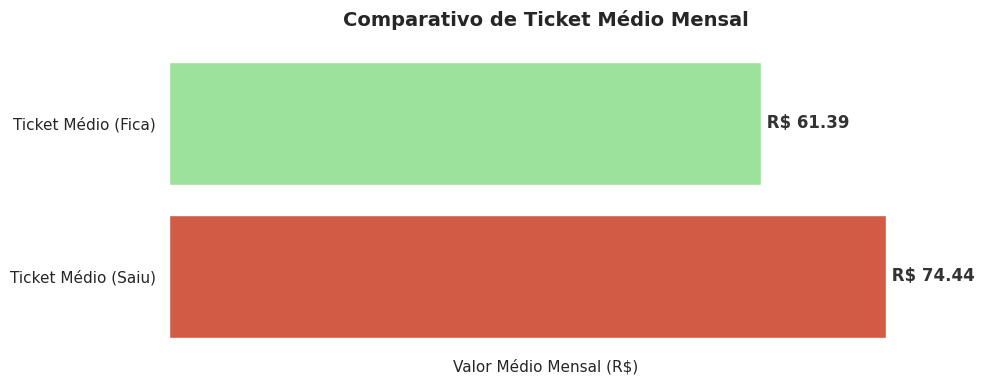

In [380]:
# Configuração de estilo
sns.set_style("white")
cores_ticket = ["#90EE90", "#e94b2f"]  # Verde para 'Fica' e Vermelho para 'Saiu'

# CÁLCULO DO TICKET MÉDIO POR STATUS
# Agrupando para pegar a média do valor mensal
df_ticket = df.groupby('evasao')['valor_mensal'].mean().reset_index()
df_ticket['evasao'] = df_ticket['evasao'].map({0: 'Ticket Médio (Fica)', 1: 'Ticket Médio (Saiu)'})

# GRÁFICO DE BARRAS HORIZONTAL
plt.figure(figsize=(10, 4))

ax = sns.barplot(data=df_ticket, x='valor_mensal', y='evasao', palette=cores_ticket)

# Títulos e Identidade Visual
plt.title('Comparativo de Ticket Médio Mensal', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Valor Médio Mensal (R$)', fontsize=11)
plt.ylabel('')

# Limpeza do gráfico
sns.despine(left=True, bottom=True)
ax.set_xticks([])

# --- 3. ANOTAÇÃO DOS VALORES NAS BARRAS ---
for i, v in enumerate(df_ticket['valor_mensal']):
    ax.text(v, i, f' R$ {v:.2f}',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='#333333')

plt.tight_layout()
plt.show()

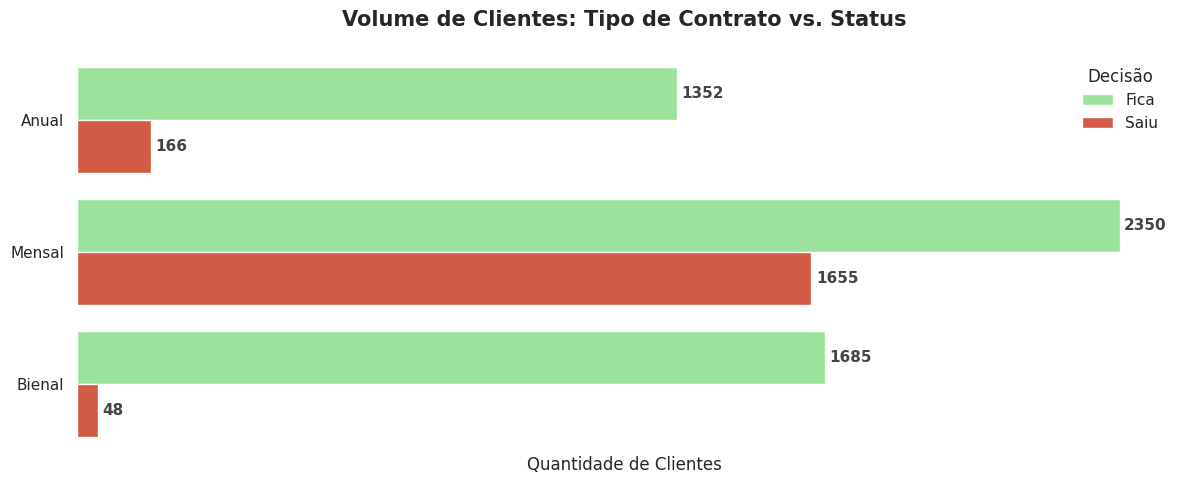

In [381]:
# Configuração de estilo e cores consistentes
sns.set_style("white")
cores_churn = ["#90EE90", "#e94b2f"]  # Verde para 'Fica' e Vermelho para 'Saiu'

# Garantindo a coluna de Status para a legenda clara
df['Status'] = df['evasao'].map({0: 'Fica', 1: 'Saiu'})

plt.figure(figsize=(12, 5))
ax1 = sns.countplot(data=df, y='tipo_contrato', hue='Status', palette=cores_churn, hue_order=['Fica', 'Saiu'])

# Títulos e Estética
plt.title('Volume de Clientes: Tipo de Contrato vs. Status', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Quantidade de Clientes', fontsize=12)
plt.ylabel('')
plt.legend(title='Decisão', frameon=False)
sns.despine(left=True, bottom=True)
ax1.set_xticks([]) # Remove o eixo X para focar nos rótulos das barras

# Adicionando os números nas barras para facilitar a leitura não técnica
for p in ax1.patches:
    largura = p.get_width()
    if largura > 0:
        ax1.annotate(f'{int(largura)}',
                     (largura + 10, p.get_y() + p.get_height()/2),
                     va='center', fontsize=11, fontweight='bold', color='#444444')

plt.tight_layout()
plt.show()

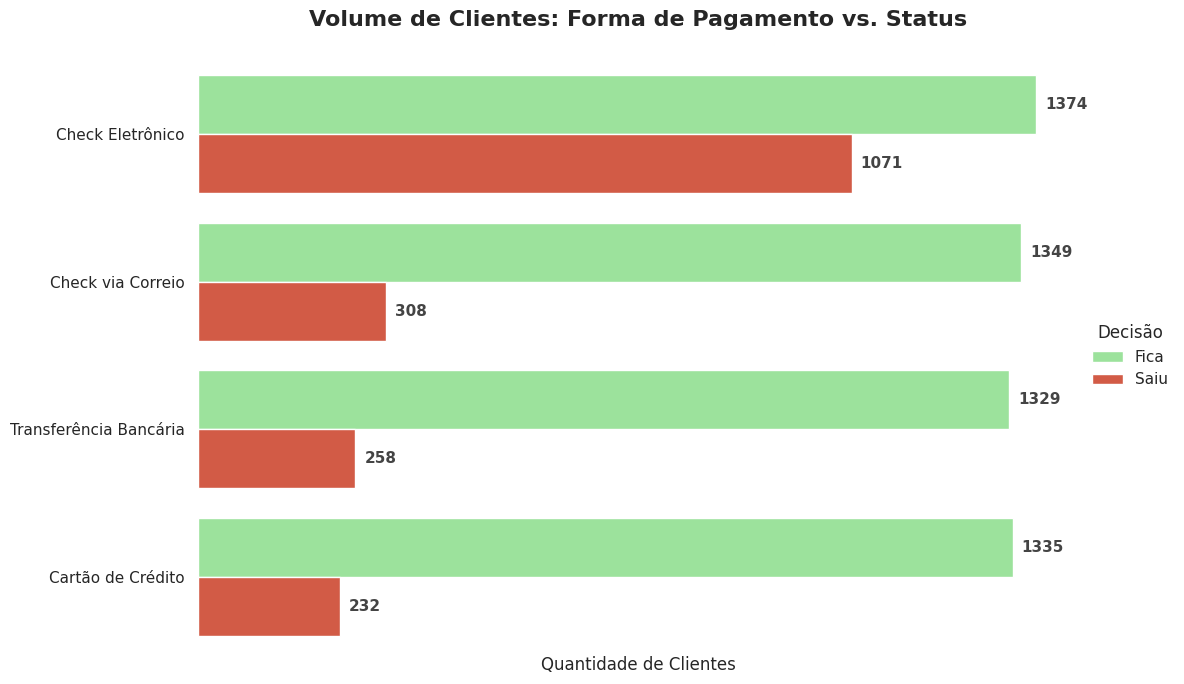

In [382]:
# GRÁFICO FORMA DE PAGAMENTO
plt.figure(figsize=(12, 7))
ordem_pagamento = df[df['evasao'] == 1]['forma_pagamento'].value_counts().index

ax2 = sns.countplot(data=df, y='forma_pagamento', hue='Status',
                   palette=cores_churn, hue_order=['Fica', 'Saiu'], order=ordem_pagamento)

plt.title('Volume de Clientes: Forma de Pagamento vs. Status', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Quantidade de Clientes', fontsize=12)
plt.ylabel('')

# AJUSTE DA LEGENDA: Fora do gráfico à direita
plt.legend(title='Decisão', title_fontsize='12', fontsize='11', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

sns.despine(left=True, bottom=True)
ax2.set_xticks([])

# Anotações nas barras
for p in ax2.patches:
    largura = p.get_width()
    if largura > 0:
        ax2.annotate(f'{int(largura)}', (largura + 15, p.get_y() + p.get_height()/2),
                     va='center', fontsize=11, fontweight='bold', color='#444444')

plt.tight_layout()
plt.show()

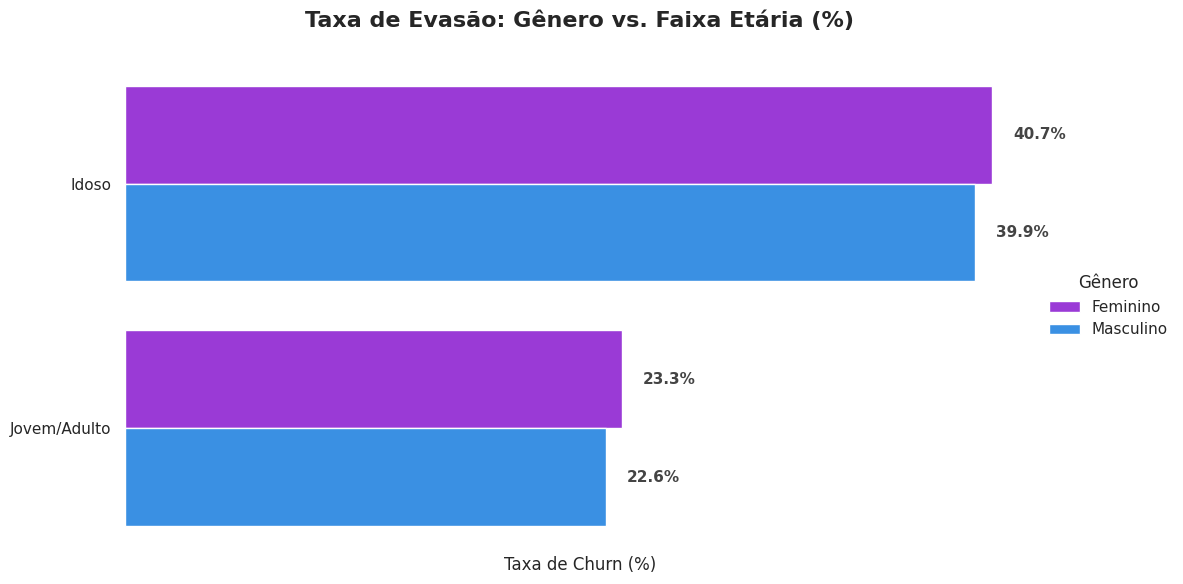

In [383]:
# Criando coluna para classificar Idoso/Jovem/Adulto
df['perfil_etario'] = df['idoso'].map({0: 'Jovem/Adulto', 1: 'Idoso'})

# --- GRÁFICO 1: EVASÃO POR GÊNERO E FAIXA ETÁRIA ---
plt.figure(figsize=(12, 6))

# Calculando a taxa de churn para os subgrupos
churn_idade_gen = df.groupby(['perfil_etario', 'genero'])['evasao'].mean().mul(100).reset_index()

ax1 = sns.barplot(data=churn_idade_gen, x='evasao', y='perfil_etario', hue='genero', palette=['#A020F0', '#1E90FF'])

# Estética Executiva
plt.title('Taxa de Evasão: Gênero vs. Faixa Etária (%)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Taxa de Churn (%)', fontsize=12)
plt.ylabel('')
plt.legend(title='Gênero', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
sns.despine(left=True, bottom=True)
ax1.set_xticks([])

# Anotações de porcentagem
for p in ax1.patches:
    largura = p.get_width()
    if largura > 0:
        ax1.annotate(f'{largura:.1f}%', (largura + 1, p.get_y() + p.get_height()/2),
                     va='center', fontsize=11, fontweight='bold', color='#444444')

plt.tight_layout()
plt.show()

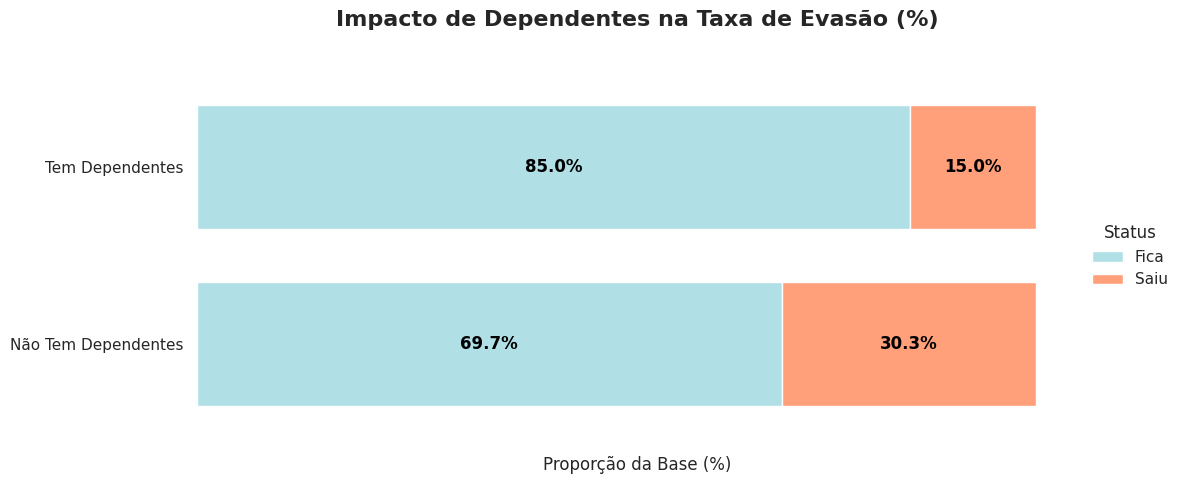

In [384]:
df_dep_plot = pd.crosstab(df['dependentes'], df['evasao'], normalize='index') * 100

# Renomeando as colunas e o índice para a legenda e o eixo Y ficarem perfeitos
df_dep_plot.columns = ['Fica', 'Saiu']
df_dep_plot.index = ['Não Tem Dependentes', 'Tem Dependentes'] # Ordem baseada no original (No/Yes)

# GRÁFICO
plt.figure(figsize=(12, 5))
cores = ["#B0E0E6", "#FFA07A"]

# Criando o gráfico de barras empilhadas
ax = df_dep_plot.plot(kind='barh', stacked=True, color=cores, width=0.7, ax=plt.gca())

# ESTÉTICA
plt.title('Impacto de Dependentes na Taxa de Evasão (%)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Proporção da Base (%)', fontsize=12)
plt.ylabel('') # O índice renomeado já explica o eixo

# Legenda externa
plt.legend(title='Status', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

sns.despine(left=True, bottom=True)
ax.set_xticks([]) # Limpa o eixo X

# RÓTULOS INTERNOS
for i, (idx, row) in enumerate(df_dep_plot.iterrows()):
    perc_saiu = row['Saiu']
    perc_fica = row['Fica']

    # Texto para 'Fica'
    plt.text(perc_fica/2, i, f'{perc_fica:.1f}%',
             va='center', ha='center', color='black', fontweight='bold')

    # Texto para 'Saiu'
    plt.text(100 - (perc_saiu/2), i, f'{perc_saiu:.1f}%',
             va='center', ha='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

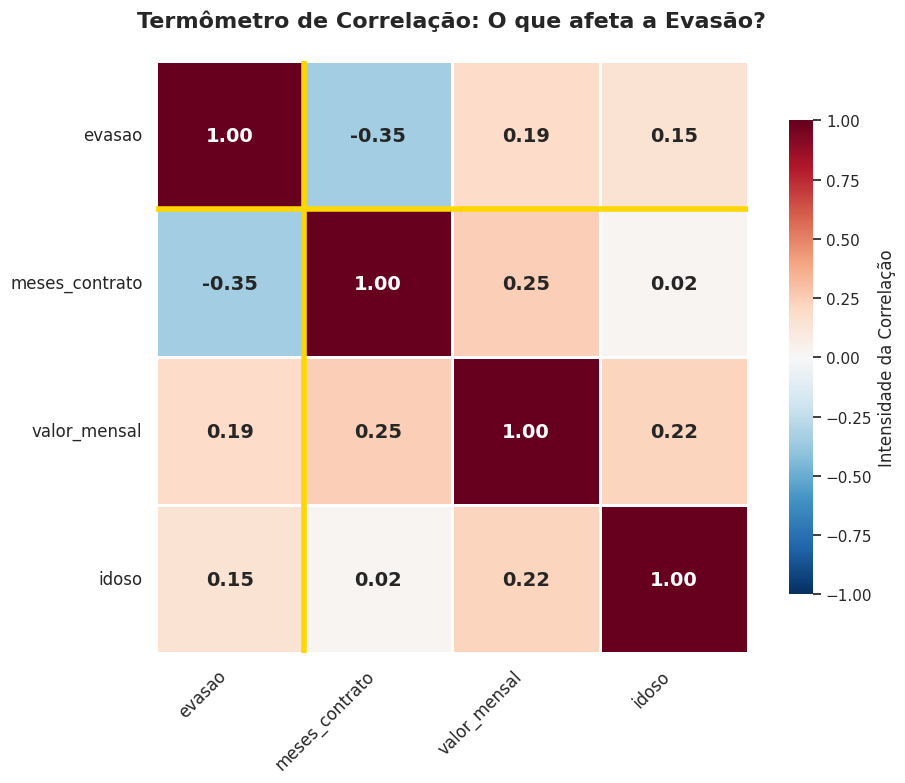


🎯 CORRELAÇÃO DAS VARIÁVEIS COM EVASÃO (O QUE REALMENTE IMPORTA!)

📊 Resultados:
⬆️ valor_mensal        : +0.189 → AUMENTA risco de evasão
⬆️ idoso               : +0.146 → AUMENTA risco de evasão
⬇️ meses_contrato      : -0.346 → DIMINUI risco de evasão

💡 INTERPRETAÇÃO:
   • Valores POSITIVOS = Aumentam a chance de evasão
   • Valores NEGATIVOS = Reduzem a chance de evasão
   • Quanto mais próximo de ±1, mais forte é a relação


In [393]:
# --- 1. PREPARAÇÃO DOS DADOS ---
colunas_analise = ['evasao', 'meses_contrato', 'valor_mensal', 'idoso']

# Matriz de correlação completa
matriz_termometro = df[colunas_analise].corr()

# --- 2. CONFIGURAÇÃO VISUAL ---
plt.figure(figsize=(10, 8))

# SEM MÁSCARA - Mostra tudo!
sns.heatmap(
    matriz_termometro,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=2,
    linecolor='white',
    cbar_kws={"shrink": .8, "label": "Intensidade da Correlação"},
    annot_kws={"size": 14, "weight": "bold"}
)

# Destacar a linha/coluna de 'evasao' com borda mais grossa
plt.axhline(y=1, color='gold', linewidth=4)  # Linha horizontal
plt.axvline(x=1, color='gold', linewidth=4)  # Linha vertical

plt.title('Termômetro de Correlação: O que afeta a Evasão?',
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# --- 3. ANÁLISE FOCADA EM EVASÃO ---
print("\n" + "="*70)
print("🎯 CORRELAÇÃO DAS VARIÁVEIS COM EVASÃO (O QUE REALMENTE IMPORTA!)")
print("="*70)

# Pegando apenas a linha/coluna de evasao (excluindo ela mesma)
correlacoes_evasao = matriz_termometro['evasao'].drop('evasao').sort_values(ascending=False)

print("\n📊 Resultados:")
for var, corr in correlacoes_evasao.items():
    simbolo = "⬆️" if corr > 0 else "⬇️"
    interpretacao = "AUMENTA" if corr > 0 else "DIMINUI"
    print(f"{simbolo} {var:20s}: {corr:+.3f} → {interpretacao} risco de evasão")

print("\n" + "="*70)
print("💡 INTERPRETAÇÃO:")
print("   • Valores POSITIVOS = Aumentam a chance de evasão")
print("   • Valores NEGATIVOS = Reduzem a chance de evasão")
print("   • Quanto mais próximo de ±1, mais forte é a relação")
print("="*70)

#📄Relatorio Final

## 🎯 Objetivo do Projeto

Identificar os principais fatores que levam à evasão (churn) de clientes na TelecomX e fornecer insights acionáveis para reduzir as taxas de cancelamento e aumentar a retenção.

---

## 📈 Cenário Atual

### Números Gerais
- **Total de Clientes Analisados:** 7.267
- **Clientes Ativos:** 5.398 (74,3%)
- **Clientes que Evadiram:** 1.869 (25,7%)
- **Taxa de Evasão Geral:** 25,7%

### Impacto Financeiro
- **Receita Atual (Clientes Ativos):** `R$ 16,04 Milhões`
- **Receita Perdida (Churn):** `R$ 2,86 Milhões`
- **Impacto Total da Evasão:** Perda de ~15% da receita potencial

---

## 🔍 Principais Descobertas

### 1️⃣ **Tempo de Contrato é o Fator Mais Crítico**
- **Correlação com Evasão:** -0,35 (correlação negativa moderada)
- Clientes com **menos de 12 meses** têm taxa de evasão **muito mais alta**
- Clientes fiéis (mais tempo) raramente cancelam

**Insight:** O primeiro ano é crítico para retenção!

---

### 2️⃣ **Valor Mensal Influencia a Evasão**
- **Correlação com Evasão:** +0,25 (correlação positiva)
- Clientes com **valores mensais mais altos** tendem a evadir mais
- Média de valor mensal dos que saíram: **`R$ 74,44`**
- Média de valor mensal dos que ficaram: **`R$ 61,39`**

**Insight:** Preço elevado sem valor percebido aumenta cancelamentos.

---

### 3️⃣ **Perfil Demográfico**

#### Idade
- **Idosos (65+):** Taxa de evasão ligeiramente maior
- **Correlação:** +0,15 (fraca, mas presente)

#### Gênero
- **Masculino:** 25,9% de evasão
- **Feminino:** 25,5% de evasão
- Diferença não é estatisticamente significativa

**Insight:** Idade tem mais peso que gênero na decisão de cancelamento.

---

### 4️⃣ **Tipo de Contrato**

| Tipo de Contrato | Taxa de Evasão |
|------------------|----------------|
| **Mensal**       | **~42%** ❌    |
| **Anual**        | **~11%** ✅    |
| **Bienal**       | **~3%** ✅✅   |

**Insight:** Contratos de longo prazo retêm clientes de forma muito mais eficaz!

---

### 5️⃣ **Forma de Pagamento**

| Método de Pagamento          | Taxa de Evasão |
|------------------------------|----------------|
| **Check Eletrônico**         | **~45%** ❌    |
| **Check via Correio**        | **~19%**       |
| **Transferência Bancária**   | **~17%**       |
| **Cartão de Crédito**        | **~15%** ✅    |

**Insight:** Check eletrônico apresenta a maior taxa de evasão. Pagamentos automáticos retêm melhor.

---

### 6️⃣ **Serviços Contratados**

Clientes com **menos serviços adicionais** evadem mais:
- **Segurança Online:** Reduz evasão
- **Backup Online:** Reduz evasão
- **Suporte Técnico:** Reduz evasão
- **Proteção de Dispositivo:** Reduz evasão

**Insight:** Quanto mais serviços agregados, maior o engajamento e menor a evasão.

---

## 💡 Recomendações Estratégicas

### ✅ **AÇÕES PRIORITÁRIAS**

#### 1. **Programa de Retenção no Primeiro Ano**
- Criar estratégias de engajamento nos primeiros 3-6 meses
- Oferecer suporte proativo e benefícios exclusivos
- Realizar pesquisas de satisfação trimestrais

#### 2. **Incentivar Contratos de Longo Prazo**
- Oferecer descontos atrativos para contratos anuais e bienais
- Criar programas de fidelidade com benefícios crescentes
- Comunicar claramente as vantagens da permanência

#### 3. **Revisar Estrutura de Preços**
- Analisar a relação custo-benefício dos planos de maior valor
- Criar pacotes intermediários mais competitivos
- Oferecer upgrades progressivos com valor agregado

#### 4. **Promover Pagamento Automático**
- Incentivar migração para cartão de crédito/débito automático
- Oferecer descontos para quem adotar pagamento recorrente
- Facilitar o processo de cadastro

#### 5. **Cross-sell de Serviços Adicionais**
- Educar clientes sobre benefícios de segurança e backup
- Criar pacotes combo com descontos
- Demonstrar valor através de cases de uso

---

## 📊 Matriz de Correlação - Resumo

| Variável              | Correlação com Evasão | Interpretação                    |
|-----------------------|-----------------------|----------------------------------|
| Meses de Contrato     | **-0,35**            | ⬇️ Mais tempo = Menos evasão     |
| Valor Mensal          | **+0,25**            | ⬆️ Maior valor = Mais evasão     |
| Valor Diário          | **+0,25**            | ⬆️ Maior valor = Mais evasão     |
| Idoso                 | **+0,15**            | ⬆️ Idosos evadem um pouco mais   |

---

## 🎯 Indicadores de Sucesso (KPIs)

Para medir o impacto das ações recomendadas:

1. **Taxa de Evasão Mensal:** Meta de redução de 25,7% para **<20%** em 12 meses
2. **Conversão para Contratos Longos:** Aumentar de ~30% para **50%**
3. **Ticket Médio x Retenção:** Manter ticket médio sem aumentar evasão
4. **Adoção de Pagamento Automático:** De 40% para **65%**
5. **Cross-sell de Serviços:** Aumentar média de serviços por cliente de 2,5 para **3,5**

---

## 🏆 Conclusão

A análise revelou que **tempo de contrato, valor mensal e tipo de contrato** são os fatores mais determinantes para a evasão na TelecomX.

Através de ações focadas em **retenção nos primeiros meses**, **incentivos para contratos longos** e **otimização de preços**, é possível reduzir significativamente a taxa de churn e aumentar o LTV (Lifetime Value) dos clientes.

---
**Fonte de Dados:** TelecomX Customer Database (7.267 registros)